# Generalization analysis — paper figures (C1 audit, C2 UQ, C4 features)
Produces every number and figure for the Water-journal manuscript into `Model/paper_figures/`. Models reuse the hyperparameters tuned in `interp_row_42` (fixed across folds so fold differences reflect data, not tuning).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'savefig.dpi': 300,
})
SEED = lp.SEED
FIG_DIR = lp.MODEL_DIR / 'paper_figures'
FIG_DIR.mkdir(exist_ok=True)
print('Figures ->', FIG_DIR)

Figures -> /home/trunght/workspace/researches/Green-X Project-BaoTien/Model/paper_figures


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
y = df['RR %']
groups = df['Id'].values
X = df.drop(columns=['Id', 'RR %'])
saved = joblib.load(lp.MODEL_DIR / 'interp_row_42' / 'saved_models.joblib')
MODELS = {k: saved[k] for k in ('LR', 'KNN', 'ANN', 'Cubist', 'RF', 'XGB', 'HistGB')}
print(f"{len(df)} rows, {df['Id'].nunique()} studies, {X.shape[1]} features")

1342 rows, 59 studies, 30 features


## C1a. Leave-one-study-out audit
Each of the 59 studies is held out once; models are refit on the remaining 58 with fixed hyperparameters.

In [3]:
loso = lp.loso_evaluation(MODELS, X.reset_index(drop=True), y.reset_index(drop=True), groups)
loso.to_csv(FIG_DIR / 'loso_per_study.csv', index=False)
summary = (loso.groupby('model')[['mae', 'rmse']]
           .agg(['median', lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)]))
summary.columns = ['MAE_med', 'MAE_q25', 'MAE_q75', 'RMSE_med', 'RMSE_q25', 'RMSE_q75']
summary = summary.sort_values('MAE_med').round(2)
summary.to_csv(FIG_DIR / 'loso_summary.csv')
summary

,MAE_med,MAE_q25,MAE_q75,RMSE_med,RMSE_q25,RMSE_q75
model,,,,,,
Cubist,14.11,4.68,22.16,15.35,4.68,26.91
KNN,16.00,6.50,30.31,16.90,6.50,34.03
HistGB,16.40,4.66,25.83,19.33,4.66,28.33
RF,16.81,6.07,25.86,18.99,6.07,27.56
ANN,18.13,11.53,38.60,20.88,11.59,42.67
XGB,18.33,3.83,25.44,21.05,3.83,29.20
LR,28.40,18.41,34.77,29.99,19.99,34.79


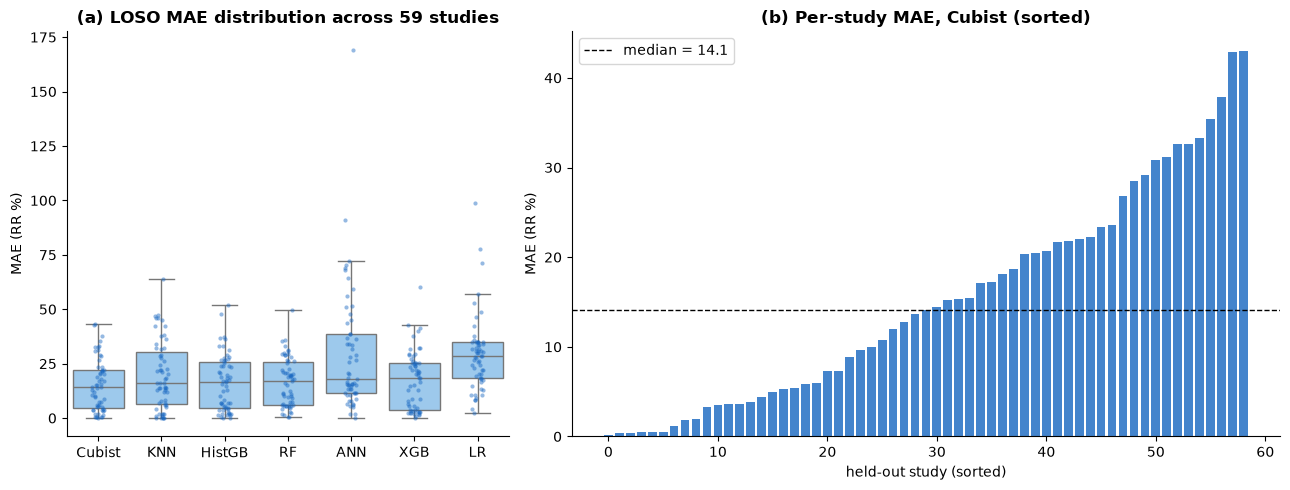

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1, 1.6]})
order = summary.index.tolist()
sns.boxplot(data=loso, x='model', y='mae', order=order, ax=axes[0], color='#90CAF9',
            showfliers=False)
sns.stripplot(data=loso, x='model', y='mae', order=order, ax=axes[0], color='#1565C0',
              alpha=0.45, size=3)
axes[0].set_title('(a) LOSO MAE distribution across 59 studies')
axes[0].set_xlabel(''); axes[0].set_ylabel('MAE (RR %)')

best = order[0]
per_study = (loso[loso.model == best].sort_values('mae')
             .reset_index(drop=True))
axes[1].bar(range(len(per_study)), per_study['mae'], color='#1565C0', alpha=0.8)
axes[1].set_title(f'(b) Per-study MAE, {best} (sorted)')
axes[1].set_xlabel('held-out study (sorted)'); axes[1].set_ylabel('MAE (RR %)')
axes[1].axhline(per_study['mae'].median(), ls='--', color='k', lw=1,
                label=f"median = {per_study['mae'].median():.1f}")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_loso_audit.png', bbox_inches='tight')
plt.show()

## C1b. Interpolation vs unseen-study performance, and learning curve

In [5]:
interp = pd.read_csv(lp.MODEL_DIR / 'interp_row_42' / 'model_scores.csv', index_col=0)
loso_med = loso.groupby('model')['mae'].median()
cmp = pd.DataFrame({'interpolation MAE (hold-out)': interp['test_mae'],
                    'unseen-study MAE (LOSO median)': loso_med}).dropna()
cmp = cmp.sort_values('interpolation MAE (hold-out)').round(2)
cmp.to_csv(FIG_DIR / 'interp_vs_loso.csv')
cmp

,interpolation MAE (hold-out),unseen-study MAE (LOSO median)
XGB,5.46,18.33
HistGB,5.62,16.40
KNN,7.73,16.00
Cubist,8.10,14.11
RF,8.35,16.81
ANN,14.11,18.13
LR,17.22,28.40


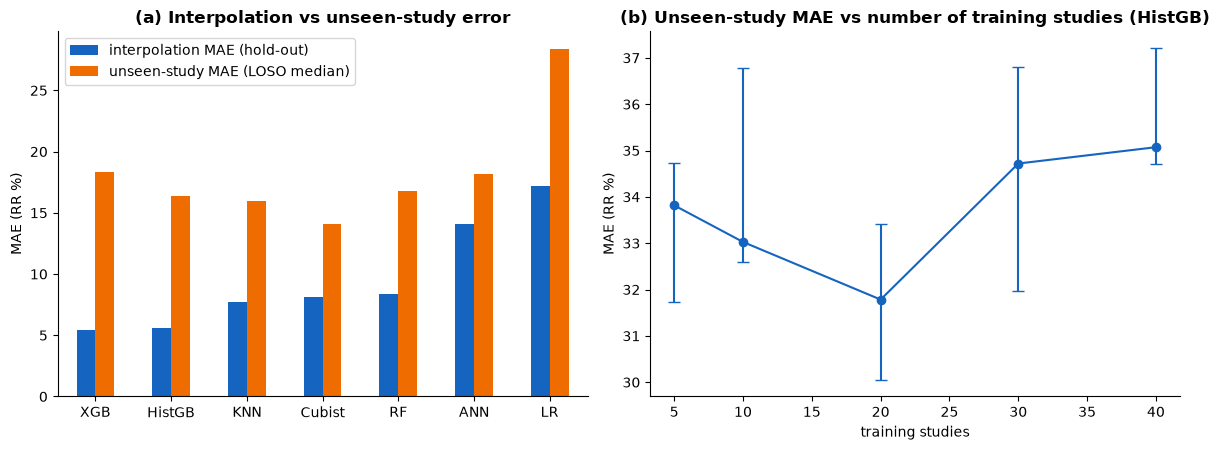

In [6]:
lc = lp.learning_curve_by_studies(MODELS['HistGB'], X, y, groups,
                                  sizes=(5, 10, 20, 30, 40), n_repeats=10)
lc.to_csv(FIG_DIR / 'learning_curve.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
cmp.plot.bar(ax=axes[0], rot=0, color=['#1565C0', '#EF6C00'])
axes[0].set_title('(a) Interpolation vs unseen-study error')
axes[0].set_ylabel('MAE (RR %)')

g = lc.groupby('n_studies')['mae']
axes[1].errorbar(g.median().index, g.median(), yerr=[g.median()-g.quantile(0.25),
                 g.quantile(0.75)-g.median()], marker='o', color='#1565C0', capsize=4)
axes[1].set_title('(b) Unseen-study MAE vs number of training studies (HistGB)')
axes[1].set_xlabel('training studies'); axes[1].set_ylabel('MAE (RR %)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_learning_curve.png', bbox_inches='tight')
plt.show()

## C2. Conformal prediction intervals and applicability domain
Split-conformal 90% intervals under both tasks. For the new-study task the calibration set is grouped by study, matching deployment.

In [7]:
model = MODELS['HistGB']
rows = []

# (a) interpolation task: same protocol as interp_row_42
keep = ~X.duplicated(keep='first')
Xd, yd, gd = X[keep], y[keep], groups[keep]
Xtr, Xte, ytr, yte, _ = lp.make_split(Xd, yd, groups=None, test_size=0.2, seed=SEED)
cf_i = lp.split_conformal(model, Xtr, ytr, Xte, yte, alpha=0.1)
rows.append({'task': 'interpolation', 'nominal': 0.90, 'coverage': cf_i['coverage'],
             'half_width_q': cf_i['q']})

# (b) new-study task: grouped split + grouped calibration
Xtr_g, Xte_g, ytr_g, yte_g, gtr = lp.make_split(Xd, yd, groups=gd, test_size=0.2, seed=SEED)
cf_g = lp.split_conformal(model, Xtr_g, ytr_g, Xte_g, yte_g, alpha=0.1, groups_tr=gtr)
rows.append({'task': 'unseen studies', 'nominal': 0.90, 'coverage': cf_g['coverage'],
             'half_width_q': cf_g['q']})

conf_table = pd.DataFrame(rows).round(3)
conf_table.to_csv(FIG_DIR / 'conformal_coverage.csv', index=False)
conf_table

,task,nominal,coverage,half_width_q
0,interpolation,0.9,0.933,18.774
1,unseen studies,0.9,0.989,67.617


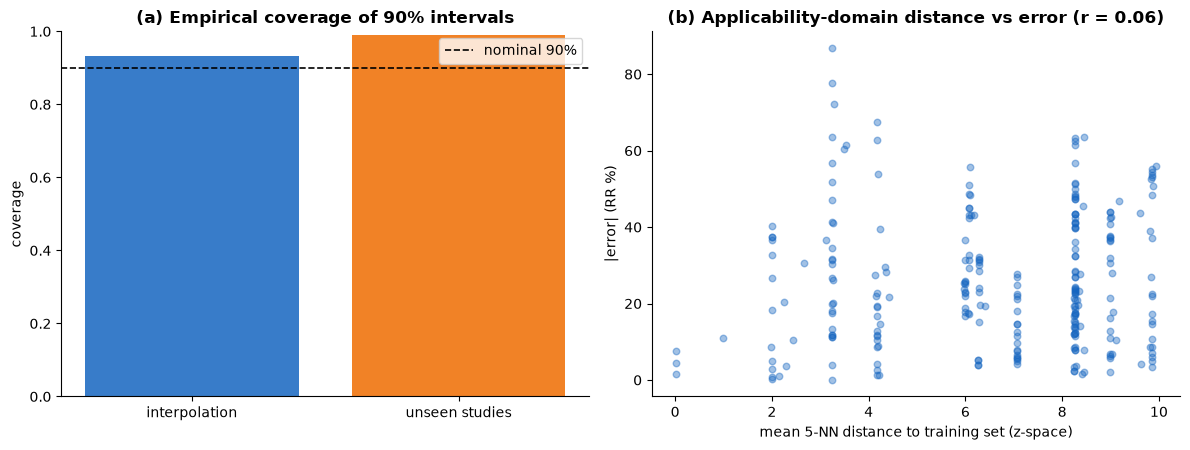

corr(AD distance, |error|) = 0.060


In [8]:
ad = lp.applicability_domain(cf_g['model'], Xtr_g, Xte_g)
abs_err = np.abs(np.asarray(yte_g, dtype=float) - cf_g['pred'])
r = np.corrcoef(ad, abs_err)[0, 1]
pd.DataFrame({'ad_distance': ad, 'abs_error': abs_err}).to_csv(
    FIG_DIR / 'applicability_domain.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(conf_table['task'], conf_table['coverage'], color=['#1565C0', '#EF6C00'],
            alpha=0.85)
axes[0].axhline(0.9, ls='--', color='k', lw=1.2, label='nominal 90%')
axes[0].set_ylim(0, 1); axes[0].set_title('(a) Empirical coverage of 90% intervals')
axes[0].set_ylabel('coverage'); axes[0].legend()

axes[1].scatter(ad, abs_err, alpha=0.4, s=22, color='#1565C0')
axes[1].set_title(f'(b) Applicability-domain distance vs error (r = {r:.2f})')
axes[1].set_xlabel('mean 5-NN distance to training set (z-space)')
axes[1].set_ylabel('|error| (RR %)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_conformal_ad.png', bbox_inches='tight')
plt.show()
print(f'corr(AD distance, |error|) = {r:.3f}')

## C4. Chemistry-informed features
Adds `pH − pHpzc` (electrostatic driving force), `Ci/AD` (initial loading), and the hydrophobicity interaction; compares both tasks with/without, then reads SHAP dependence mechanistically.

In [9]:
cfg_eng = lp.ExperimentConfig(name='interp_row_eng_42', split_mode='row',
                              dedup_features=True, engineered_features=True,
                              models=("Cubist", "RF", "XGB", "HistGB"))
run_eng = lp.run_experiment(cfg_eng, df)

X_eng = lp.add_engineered_features(X)
loso_eng = lp.loso_evaluation({'HistGB': run_eng['results']['HistGB']['model']},
                              X_eng.reset_index(drop=True), y.reset_index(drop=True),
                              groups)
feat_cmp = pd.DataFrame({
    'interpolation test MAE': {
        'raw features': interp.loc['HistGB', 'test_mae'],
        'with engineered': run_eng['table'].loc['HistGB', 'test_mae']},
    'unseen-study median MAE': {
        'raw features': loso_med['HistGB'],
        'with engineered': loso_eng['mae'].median()},
}).round(2)
feat_cmp.to_csv(FIG_DIR / 'engineered_features_effect.csv')
feat_cmp

[interp_row_eng_42] dropped 83 exact feature-duplicate rows
[interp_row_eng_42] split=row  train=1007  test=252  features=33
--- Optuna tuning RF (30 trials) ---


[*] RF best params: {'n_estimators': 344, 'max_depth': 13, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---


[*] XGB best params: {'n_estimators': 345, 'learning_rate': 0.09849869723467915, 'max_depth': 13, 'min_child_weight': 7}
--- Optuna tuning HistGB (30 trials) ---


[*] HistGB best params: {'max_iter': 273, 'learning_rate': 0.08232588474537599, 'max_depth': 12, 'min_samples_leaf': 5}
--- Cubist ---


[*] best params: {'n_committees': 9, 'neighbors': 1}


    Train      R2  0.9383 | MAE   3.6632
    CV (valid) R2  0.7845 | MAE   8.3731
    Test       R2  0.7819 | MAE   8.5668

--- RF ---


    Train      R2  0.9102 | MAE   5.4562
    CV (valid) R2  0.7746 | MAE   8.9928
    Test       R2  0.8026 | MAE   8.2565

--- XGB ---


    Train      R2  0.9945 | MAE   0.9649
    CV (valid) R2  0.8346 | MAE   6.8213
    Test       R2  0.8506 | MAE   5.8062

--- HistGB ---


    Train      R2  0.9917 | MAE   1.5952
    CV (valid) R2  0.8361 | MAE   6.9262
    Test       R2  0.8615 | MAE   5.7629



,interpolation test MAE,unseen-study median MAE
raw features,5.62,16.40
with engineered,5.76,15.96


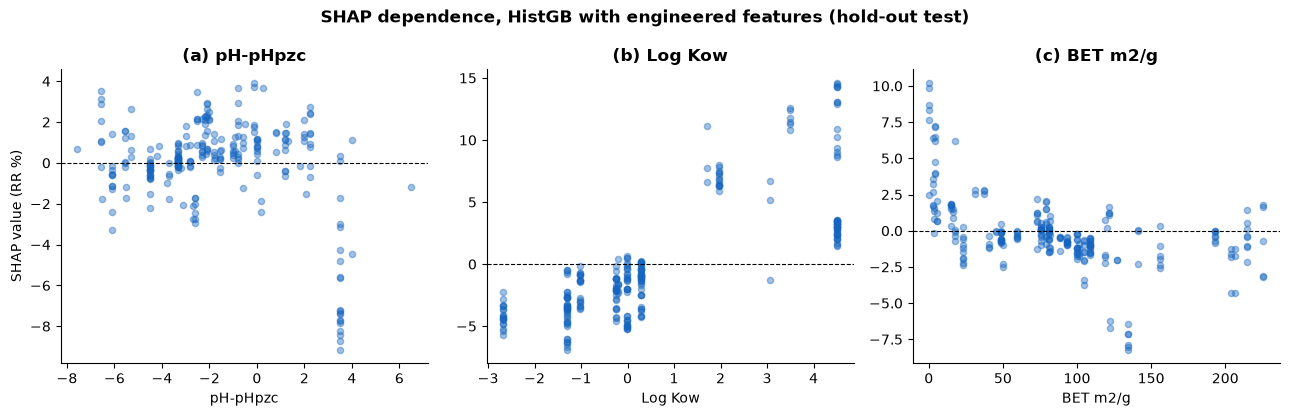

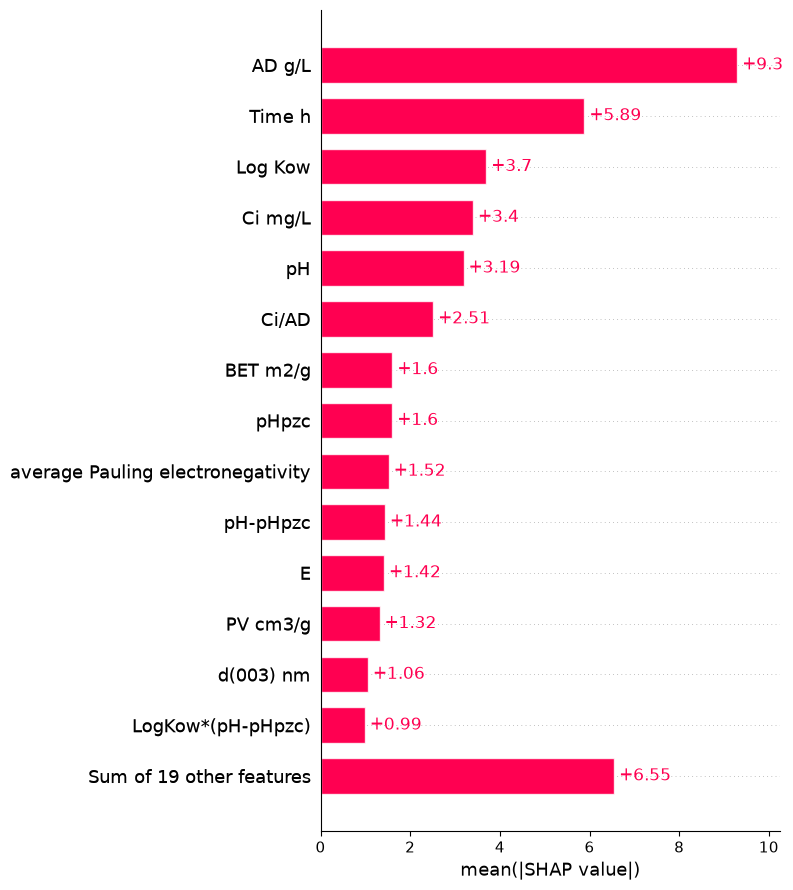

In [10]:
import shap
res_best = run_eng['results']['HistGB']
sv, names = lp.shap_summary(res_best, run_eng['X_test'])
sv.feature_names = names

fig = plt.figure(figsize=(13, 4.2))
for i, feat in enumerate(['pH-pHpzc', 'Log Kow', 'BET m2/g']):
    ax = plt.subplot(1, 3, i + 1)
    j = names.index(feat)
    ax.scatter(sv.data[:, j], sv.values[:, j], alpha=0.4, s=20, color='#1565C0')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel(feat); ax.set_ylabel('SHAP value (RR %)' if i == 0 else '')
    ax.set_title(f'({chr(97+i)}) {feat}')
plt.suptitle('SHAP dependence, HistGB with engineered features (hold-out test)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_mechanism.png', bbox_inches='tight')
plt.show()

shap.plots.bar(sv, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_bar_eng.png', bbox_inches='tight')
plt.show()

## Outputs
All CSVs and figures for the manuscript are in `Model/paper_figures/`; every number cited in the paper traces back to one of these files.